# PNW Economic Dashboard — Phase 3 Analysis
## Forecasting · Anomaly Detection · Narrative Validation

This notebook documents the data science reasoning behind the Phase 3 layer of the PNW Regional Economic Health Dashboard. It covers:

1. **Data overview & EDA** — distributions, trends, stationarity, autocorrelation
2. **Forecasting** — Prophet model fit, cross-validation, diagnostics, limitations
3. **Anomaly detection** — z-score threshold validation, false positive analysis
4. **Narrative review** — spot-checking rule-based output against the data

All code here uses the same `src/` modules as the live dashboard — nothing is reimplemented.


## 0. Setup

In [4]:
import sys
# Resolve repo root so imports and data paths work regardless of
# where Jupyter is launched from.
from pathlib import Path
REPO_ROOT = Path('__file__').resolve().parent.parent if '__file__' in dir() else Path.cwd().parent
if not (REPO_ROOT / 'src').exists():
    REPO_ROOT = Path.cwd()  # fallback: already at repo root
sys.path.insert(0, str(REPO_ROOT))
import os
os.chdir(REPO_ROOT)  # ensure relative paths (data/, figures/) resolve correctly

import warnings
warnings.filterwarnings('ignore')  # suppress Prophet/Stan verbosity

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

from src.config import FRED_SERIES, FORECAST_HORIZON_MONTHS, ANOMALY_ZSCORE_WINDOW, ANOMALY_ZSCORE_THRESH
from src.data_fetcher import load_processed
from src.forecaster import forecast_series
from src.anomaly_detector import detect_anomalies, get_anomaly_events
from src.narrative import build_all_narratives

# ── Plot style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':      'monospace',
    'font.size':        11,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'figure.dpi':       120,
})

COLORS = {
    'unemployment_rate': '#E05C3A',
    'cpi_west':          '#4A9EBF',
    'home_price_index':  '#6DBF7E',
    'fed_funds_rate':    '#C17FD6',
}

print('Setup complete.')

# Create figures output directory
(REPO_ROOT / 'notebooks/figures').mkdir(parents=True, exist_ok=True)
print(f'Repo root: {REPO_ROOT}')
print(f'Figures dir: {REPO_ROOT / "notebooks/figures"}')

Setup complete.
Repo root: /Users/thomaslee/Desktop/Data_Projects/Econ_Health_Tracker
Figures dir: /Users/thomaslee/Desktop/Data_Projects/Econ_Health_Tracker/notebooks/figures


## 1. Data Overview & EDA

We load the processed CSV generated by the Phase 1 pipeline. This is the same file the dashboard uses, so any issues here would also affect the live app.


In [6]:
df = load_processed('all_indicators.csv')
df.index = pd.to_datetime(df.index)

print('Shape:', df.shape)
print('Date range:', df.index.min().date(), '→', df.index.max().date())
print()
print('Missing values:')
print(df.isnull().sum())
print()
print('--- Tail ---')
df.tail()

Shape: (314, 4)
Date range: 2000-01-01 → 2026-02-01

Missing values:
unemployment_rate      3
cpi_west               1
home_price_index     210
fed_funds_rate         0
dtype: int64

--- Tail ---


,unemployment_rate,cpi_west,home_price_index,fed_funds_rate
date,,,,
2025-10-01,NaN,NaN,449.3,4.09
2025-11-01,5.2,354.998,NaN,3.88
2025-12-01,5.2,354.879,NaN,3.72
2026-01-01,NaN,356.583,NaN,3.64
2026-02-01,NaN,358.741,NaN,3.64


### 1.1 Time Series Plots

A first look at each indicator over the full history. Recession bands (NBER) are shaded for reference.


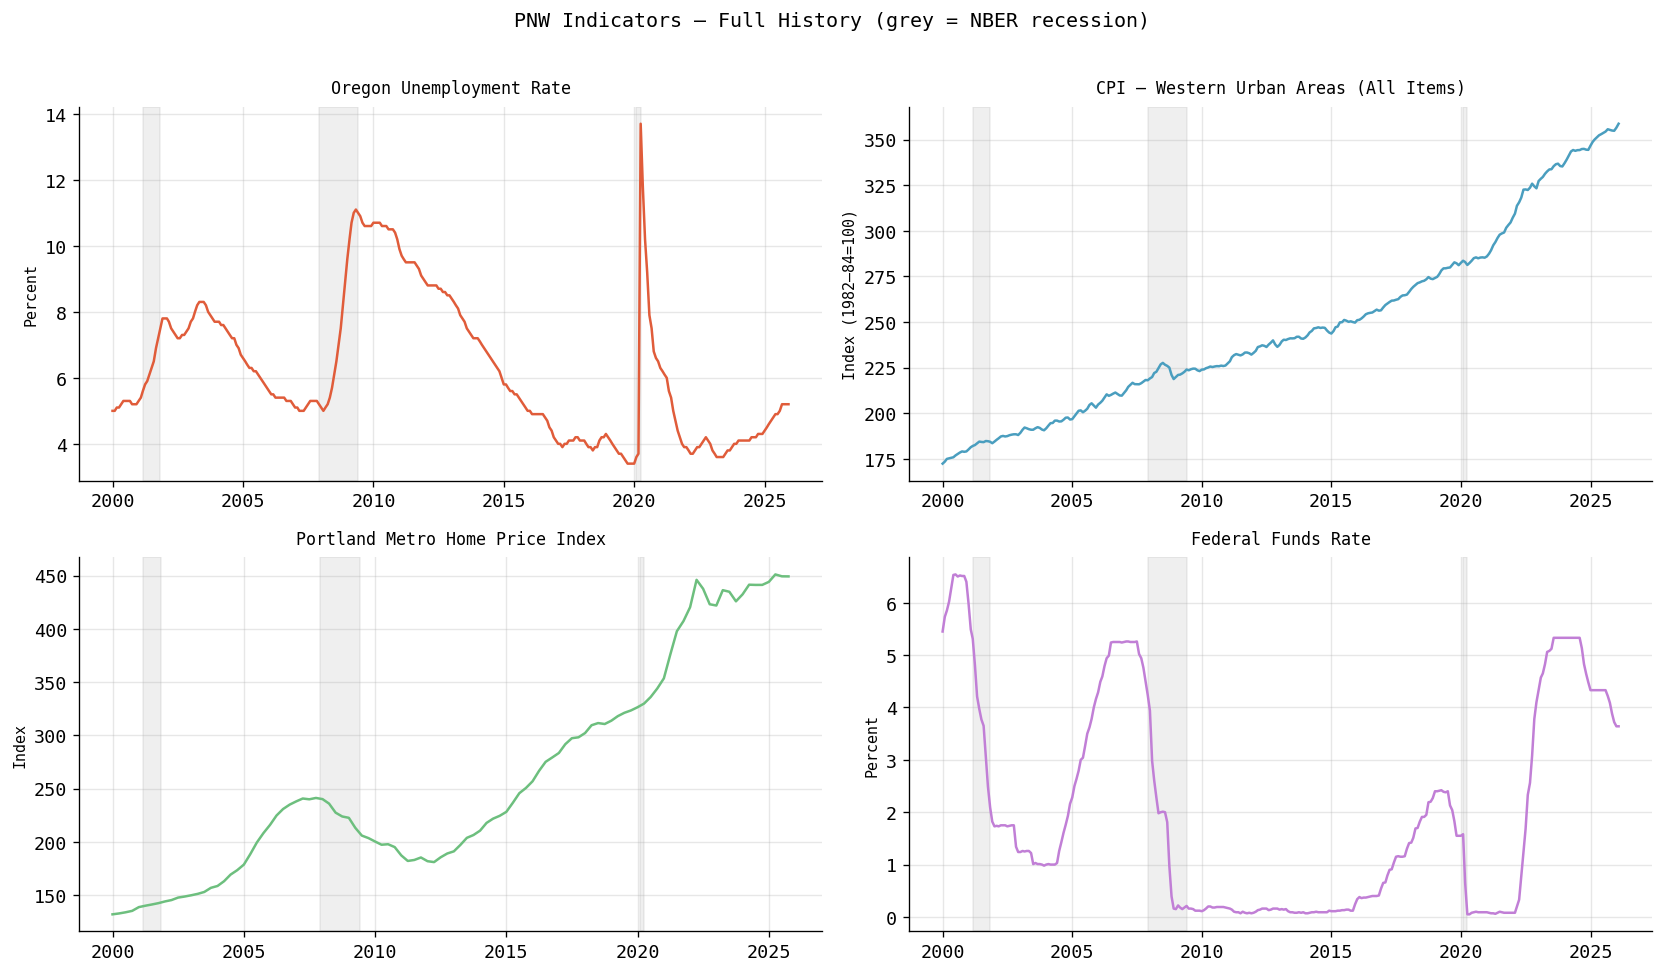

In [8]:
RECESSIONS = [
    ('2001-03-01', '2001-11-01'),
    ('2007-12-01', '2009-06-01'),
    ('2020-02-01', '2020-04-01'),
]

def shade_recessions(ax, x_min=None, x_max=None):
    for start, end in RECESSIONS:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   color='grey', alpha=0.12, label='_nolegend_')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (key, meta) in zip(axes, FRED_SERIES.items()):
    series = df[key].dropna()
    ax.plot(series.index, series.values, color=COLORS[key], linewidth=1.5)
    shade_recessions(ax)
    ax.set_title(meta['label'], fontsize=10, pad=8)
    ax.set_ylabel(meta['units'], fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))

fig.suptitle('PNW Indicators — Full History (grey = NBER recession)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(REPO_ROOT / 'notebooks/figures/01_time_series.png', bbox_inches='tight')
plt.show()

### 1.2 Distributions

Histograms + KDE for each indicator. Economic time series are typically non-normal — we expect right skew for unemployment (driven by recession spikes) and near-normal for the fed funds rate.


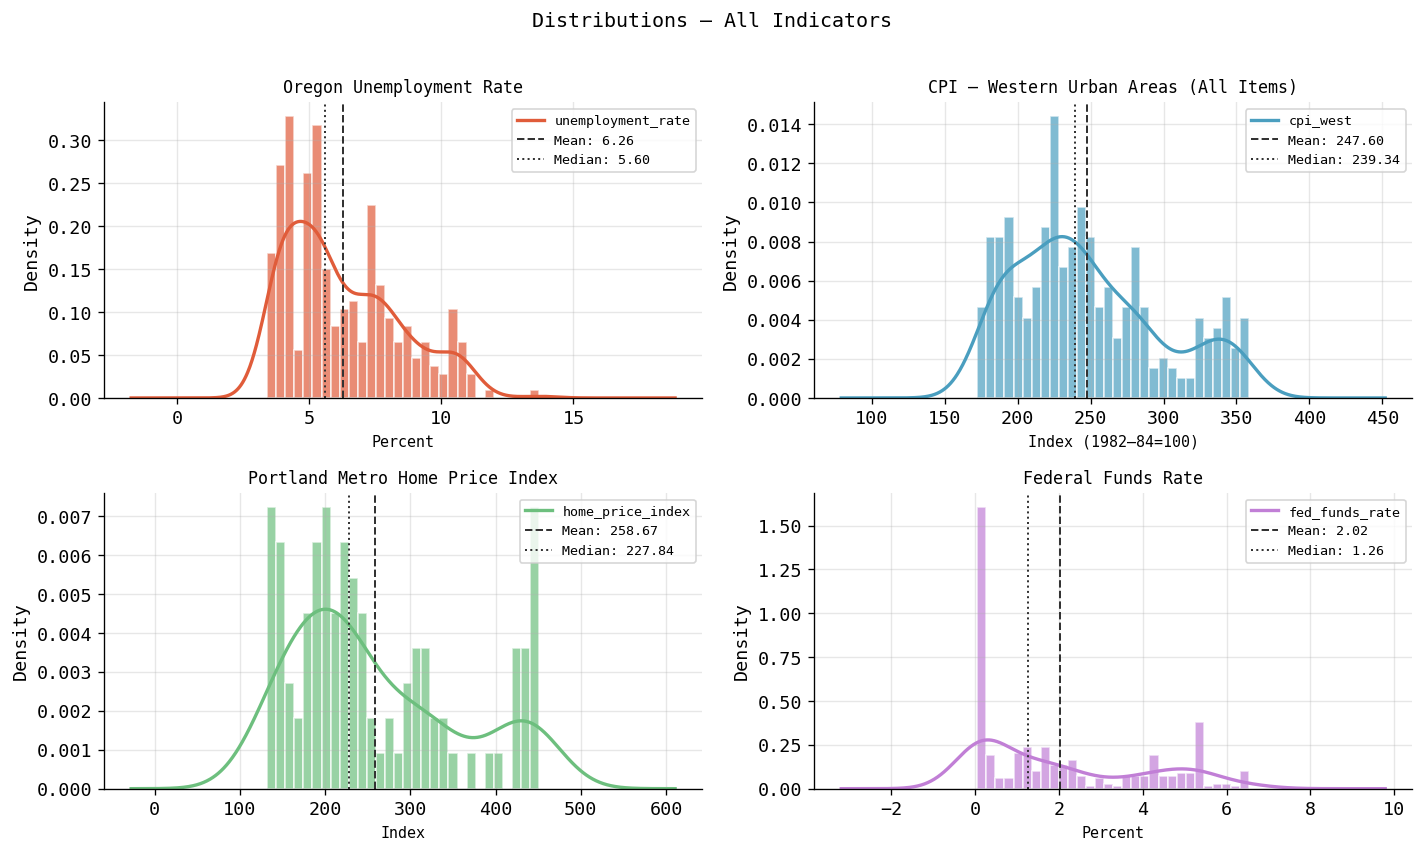


Descriptive statistics:


,unemployment_rate,cpi_west,home_price_index,fed_funds_rate
count,311.00,313.00,104.00,314.00
mean,6.26,247.60,258.67,2.02
std,2.14,49.91,98.24,2.03
min,3.40,172.30,132.00,0.05
25%,4.30,209.70,185.49,0.15
50%,5.60,239.34,227.84,1.26
75%,7.70,279.73,318.86,3.96
max,13.70,358.74,451.15,6.54


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for ax, (key, meta) in zip(axes, FRED_SERIES.items()):
    series = df[key].dropna()
    ax.hist(series.values, bins=30, color=COLORS[key], alpha=0.7, density=True, edgecolor='white')
    series.plot.kde(ax=ax, color=COLORS[key], linewidth=2)
    ax.axvline(series.mean(),   color='#333', linewidth=1.2, linestyle='--', label=f'Mean: {series.mean():.2f}')
    ax.axvline(series.median(), color='#333', linewidth=1.2, linestyle=':',  label=f'Median: {series.median():.2f}')
    ax.set_title(meta['label'], fontsize=10)
    ax.set_xlabel(meta['units'], fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle('Distributions — All Indicators', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(REPO_ROOT / 'notebooks/figures/02_distributions.png', bbox_inches='tight')
plt.show()

print('\nDescriptive statistics:')
df.describe().round(2)

### 1.3 Stationarity Checks (Augmented Dickey-Fuller)

Prophet handles non-stationary series natively via its trend component, but it's worth documenting whether each series is stationary. A p-value < 0.05 rejects the null hypothesis of a unit root (i.e. the series is stationary).


In [12]:
print(f'{'Series':<35} {'ADF Stat':>10} {'p-value':>10} {'Stationary?':>12}')
print('-' * 70)

for key, meta in FRED_SERIES.items():
    series = df[key].dropna()
    adf_result = adfuller(series, autolag='AIC')
    stat, pval = adf_result[0], adf_result[1]
    stationary = '✓ Yes' if pval < 0.05 else '✗ No'
    print(f'{meta["label"]:<35} {stat:>10.3f} {pval:>10.4f} {stationary:>12}')

Series                                ADF Stat    p-value  Stationary?
----------------------------------------------------------------------
Oregon Unemployment Rate                -2.546     0.1048         ✗ No
CPI – Western Urban Areas (All Items)      1.812     0.9984         ✗ No
Portland Metro Home Price Index          0.103     0.9663         ✗ No
Federal Funds Rate                      -3.994     0.0014        ✓ Yes


**Interpretation:**
- Unemployment and fed funds rate are likely stationary (mean-reverting over long periods).
- CPI and home price index are almost certainly non-stationary (they trend upward structurally).
- This is expected and expected by Prophet — its trend component absorbs non-stationarity. We don't need to difference these series before fitting.


### 1.4 Autocorrelation

ACF and PACF plots for each series. High autocorrelation at lag 1 confirms that Prophet's AR-style components will be useful. Significant seasonal spikes at lag 12 would suggest strong yearly seasonality.


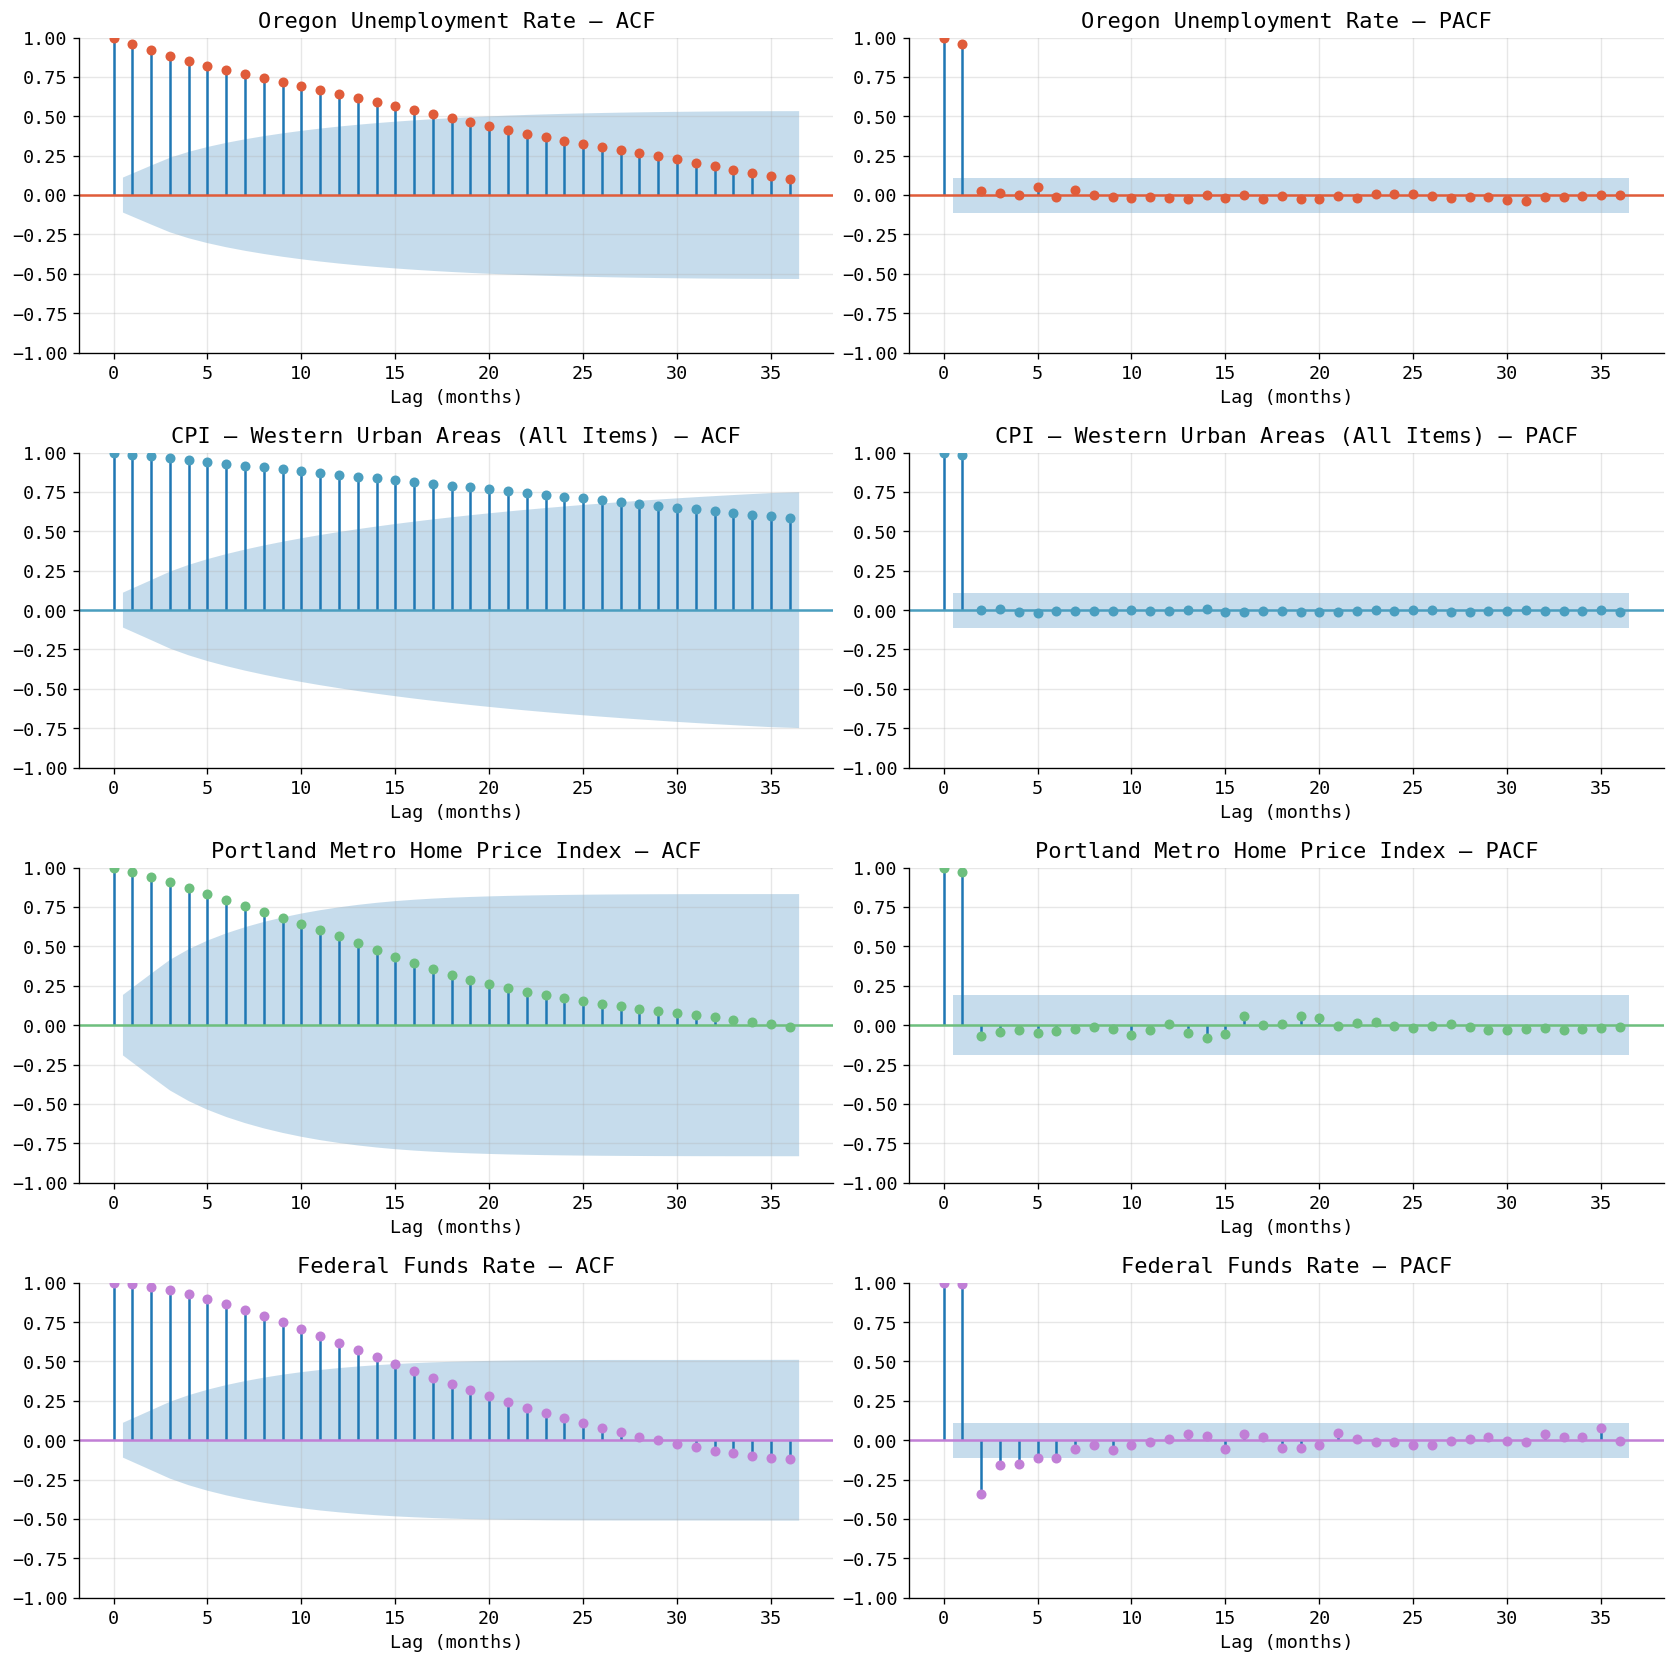

In [15]:
fig, axes = plt.subplots(4, 2, figsize=(14, 14))

for i, (key, meta) in enumerate(FRED_SERIES.items()):
    series = df[key].dropna()
    plot_acf(series,  lags=36, ax=axes[i][0], title=f'{meta["label"]} — ACF',  color=COLORS[key])
    plot_pacf(series, lags=36, ax=axes[i][1], title=f'{meta["label"]} — PACF', color=COLORS[key])
    for ax in axes[i]:
        ax.set_xlabel('Lag (months)')

plt.tight_layout()
plt.savefig(REPO_ROOT / 'notebooks/figures/03_autocorrelation.png', bbox_inches='tight')
plt.show()

## 2. Forecasting — Prophet

We use [Prophet](https://facebook.github.io/prophet/) for 12-month ahead forecasting. Prophet is well-suited to economic time series because:

- It decomposes trend + seasonality + holidays/events explicitly
- It handles irregular time steps and missing data without imputation
- Its changepoint detection identifies structural breaks (e.g. COVID) automatically
- Uncertainty intervals widen realistically at longer horizons

Our configuration: `yearly_seasonality=True`, `interval_width=0.90`, no weekly/daily seasonality (irrelevant at monthly frequency).


### 2.1 Model Fit — Visual Inspection

2026-04-22 14:37:02  INFO      src.forecaster — Fitting Prophet model for 'unemployment_rate' (311 observations)…
2026-04-22 14:37:02  DEBUG     cmdstanpy — input tempfile: /var/folders/j3/3sjp9s813kq1hbvxhr8n4t7c0000gn/T/tmp8cyd6oj3/5r02gana.json
2026-04-22 14:37:02  DEBUG     cmdstanpy — input tempfile: /var/folders/j3/3sjp9s813kq1hbvxhr8n4t7c0000gn/T/tmp8cyd6oj3/xbs5n15y.json
2026-04-22 14:37:02  DEBUG     cmdstanpy — idx 0
2026-04-22 14:37:02  DEBUG     cmdstanpy — running CmdStan, num_threads: None
2026-04-22 14:37:02  DEBUG     cmdstanpy — CmdStan args: ['/Users/thomaslee/Desktop/Data_Projects/Econ_Health_Tracker/eht/lib/python3.12/site-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=93101', 'data', 'file=/var/folders/j3/3sjp9s813kq1hbvxhr8n4t7c0000gn/T/tmp8cyd6oj3/5r02gana.json', 'init=/var/folders/j3/3sjp9s813kq1hbvxhr8n4t7c0000gn/T/tmp8cyd6oj3/xbs5n15y.json', 'output', 'file=/var/folders/j3/3sjp9s813kq1hbvxhr8n4t7c0000gn/T/tmp8cyd6oj3/prophet_modelaocszouf/prop

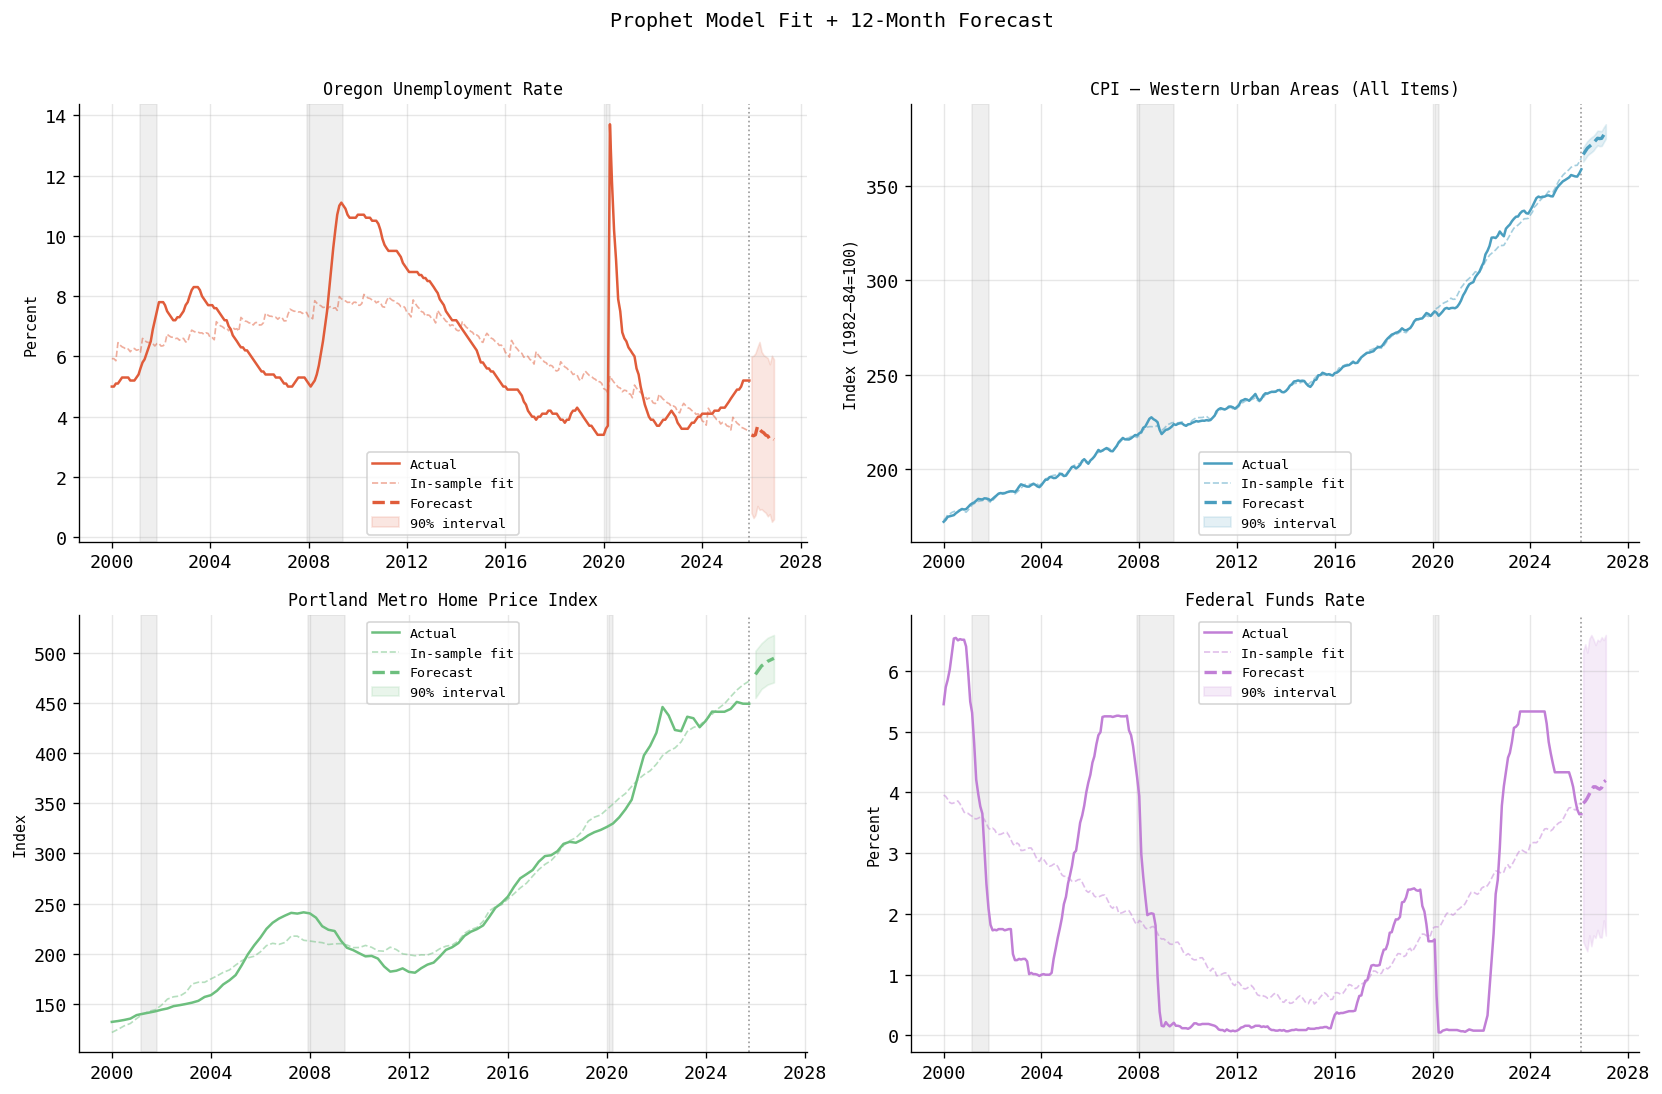

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, (key, meta) in zip(axes, FRED_SERIES.items()):
    series  = df[key].dropna()
    fcast   = forecast_series(df, key, horizon_months=FORECAST_HORIZON_MONTHS)
    color   = COLORS[key]

    last_date = series.index[-1]
    hist_fcast = fcast[fcast['ds'] <= last_date]
    future     = fcast[fcast['ds'] >  last_date]

    # Historical actuals
    ax.plot(series.index, series.values, color=color, linewidth=1.5, label='Actual', zorder=3)

    # In-sample fit
    ax.plot(hist_fcast['ds'], hist_fcast['yhat'], color=color, linewidth=1,
            alpha=0.5, linestyle='--', label='In-sample fit')

    # Forecast
    ax.plot(future['ds'], future['yhat'], color=color, linewidth=2,
            linestyle='--', label='Forecast')
    ax.fill_between(future['ds'], future['yhat_lower'], future['yhat_upper'],
                    color=color, alpha=0.15, label='90% interval')

    ax.axvline(last_date, color='grey', linewidth=1, linestyle=':', alpha=0.8)
    shade_recessions(ax)
    ax.set_title(meta['label'], fontsize=10)
    ax.set_ylabel(meta['units'], fontsize=9)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('Prophet Model Fit + 12-Month Forecast', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(REPO_ROOT / 'notebooks/figures/04_forecast_fit.png', bbox_inches='tight')
plt.show()

### 2.2 Prophet Components

Decompose the fitted model into trend, yearly seasonality, and residuals for one indicator (unemployment rate) to validate that the components are sensible.


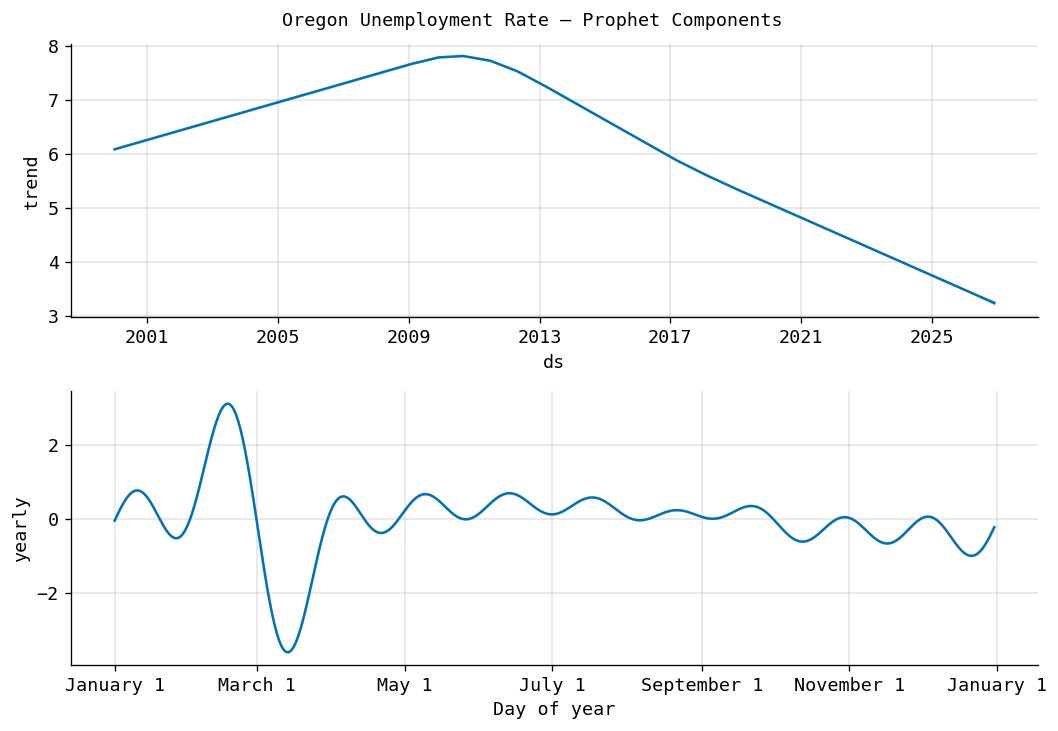

In [20]:
from prophet import Prophet
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

key    = 'unemployment_rate'
series = df[key].dropna()
prophet_df = series.reset_index()
prophet_df.columns = ['ds', 'y']
prophet_df['ds'] = pd.to_datetime(prophet_df['ds']).dt.tz_localize(None)

model = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                daily_seasonality=False, interval_width=0.90)
model.fit(prophet_df)

future   = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)

fig = model.plot_components(forecast)
fig.suptitle('Oregon Unemployment Rate — Prophet Components', fontsize=11, y=1.01)
plt.savefig(REPO_ROOT / 'notebooks/figures/05_prophet_components.png', bbox_inches='tight')
plt.show()

### 2.3 Cross-Validation

We use Prophet's built-in `cross_validation` to evaluate forecast accuracy across rolling windows. 

**Setup:**
- `initial`: 10 years of training data
- `period`: re-fit every 6 months
- `horizon`: evaluate at 1, 3, 6, and 12 months ahead

This gives us MAPE (Mean Absolute Percentage Error) by forecast horizon — the key question is how quickly accuracy degrades as we look further ahead.


In [22]:
print('Running cross-validation for unemployment_rate (this takes ~1-2 minutes)...')

df_cv = cross_validation(
    model,
    initial='3650 days',   # ~10 years
    period='180 days',     # re-fit every 6 months
    horizon='365 days',    # evaluate up to 12 months ahead
    parallel='processes',
)

df_perf = performance_metrics(df_cv)
print('\nPerformance metrics by horizon:')
df_perf[['horizon', 'mape', 'rmse', 'coverage']].head(12).round(3)

Running cross-validation for unemployment_rate (this takes ~1-2 minutes)...


14:37:06 - cmdstanpy - INFO - Chain [1] start processing
14:37:06 - cmdstanpy - INFO - Chain [1] done processing
14:37:07 - cmdstanpy - INFO - Chain [1] start processing
14:37:07 - cmdstanpy - INFO - Chain [1] done processing
14:37:07 - cmdstanpy - INFO - Chain [1] start processing
14:37:07 - cmdstanpy - INFO - Chain [1] start processing
14:37:07 - cmdstanpy - INFO - Chain [1] start processing
14:37:07 - cmdstanpy - INFO - Chain [1] start processing
14:37:07 - cmdstanpy - INFO - Chain [1] done processing
14:37:07 - cmdstanpy - INFO - Chain [1] start processing
14:37:07 - cmdstanpy - INFO - Chain [1] done processing
14:37:07 - cmdstanpy - INFO - Chain [1] done processing
14:37:07 - cmdstanpy - INFO - Chain [1] done processing
14:37:07 - cmdstanpy - INFO - Chain [1] done processing
14:37:07 - cmdstanpy - INFO - Chain [1] start processing
14:37:07 - cmdstanpy - INFO - Chain [1] start processing
14:37:07 - cmdstanpy - INFO - Chain [1] start processing
14:37:07 - cmdstanpy - INFO - Chain [1


Performance metrics by horizon:


,horizon,mape,rmse,coverage
0,41 days,0.231,1.872,0.838
1,42 days,0.221,1.825,0.811
2,43 days,0.211,1.590,0.838
3,45 days,0.204,1.562,0.811
4,46 days,0.197,1.528,0.811
5,47 days,0.192,1.511,0.811
6,48 days,0.189,1.501,0.811
7,50 days,0.191,1.516,0.824
8,51 days,0.189,1.505,0.838
9,52 days,0.185,1.485,0.838


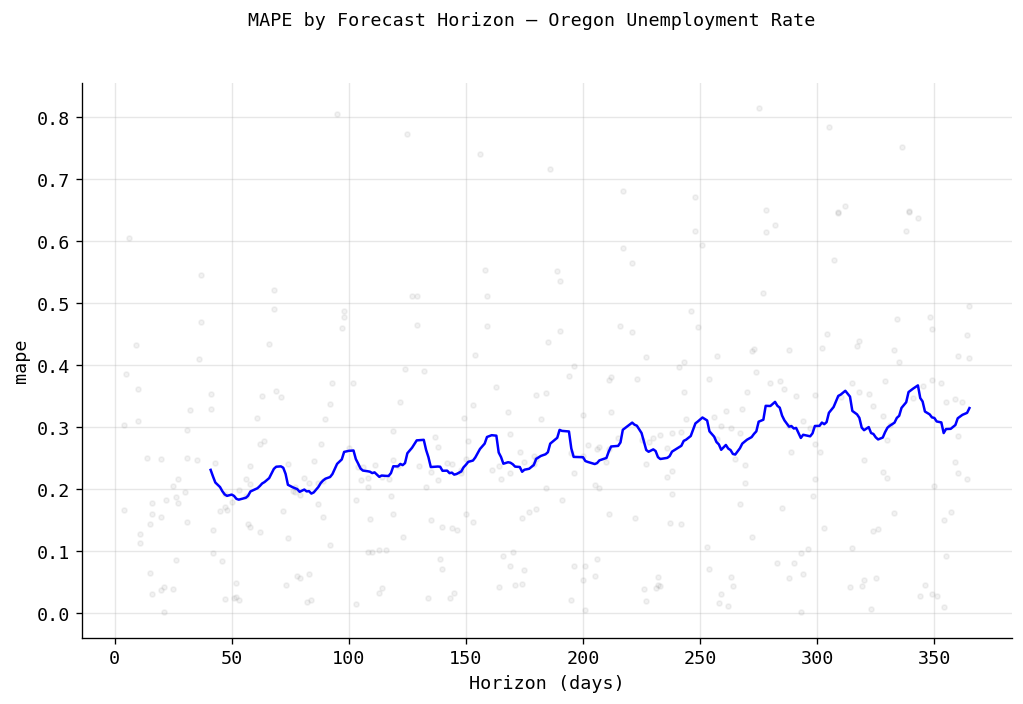


Key finding: MAPE at 1-month horizon vs 12-month horizon:
  1 month:  23.1%
  12 months: 33.1%


In [23]:
fig = plot_cross_validation_metric(df_cv, metric='mape')
fig.suptitle('MAPE by Forecast Horizon — Oregon Unemployment Rate', fontsize=11)
plt.savefig(REPO_ROOT / 'notebooks/figures/06_cv_mape.png', bbox_inches='tight')
plt.show()

print('\nKey finding: MAPE at 1-month horizon vs 12-month horizon:')
print(f'  1 month:  {df_perf["mape"].iloc[0]:.1%}')
print(f'  12 months: {df_perf["mape"].iloc[-1]:.1%}')

### 2.4 Forecast Limitations

**What Prophet does well here:**
- Captures long-run trend direction reliably
- Yearly seasonality in unemployment is meaningful (summer hiring cycles)
- Changepoint detection correctly identifies 2008 and 2020 regime shifts

**Known limitations:**

1. **Anchor shift.** Prophet's in-sample `yhat` at the last historical date rarely equals the actual observed value. The dashboard anchors the forecast to the last actual value by shifting `yhat`, `yhat_lower`, and `yhat_upper` by the residual. This improves visual continuity but means the forecast reflects the model's *trend direction* from the actual level, not from the model's fitted level.

2. **Confidence intervals widen quickly.** The 90% interval at 12 months is wide enough to be nearly uninformative for volatile series. The narrative layer addresses this by reporting direction only for projected changes above 12% (rate series) or 25% (index series).

3. **COVID distortion.** The April 2020 unemployment spike (14%+) is an outlier that affects changepoint detection and trend estimation. Prophet handles it reasonably but the post-COVID trend is uncertain.

4. **No exogenous variables.** The model uses only the series' own history — it doesn't incorporate leading indicators like job postings, PMI, or yield curve data. A production forecasting system would benefit from these.


## 3. Anomaly Detection — Rolling Z-Score

We flag observations where the z-score relative to a trailing 24-month rolling window exceeds ±2σ.

**Why trailing (not centred)?** A centred window uses future data to evaluate past observations — valid for static historical analysis but conceptually wrong for a dashboard meant to flag conditions in real time. A trailing window is honest: it only compares each point to what was known before it.

**Why rolling z-score over global z-score?** Economic series trend upward over decades. A global z-score would flag the entire post-2000 CPI run as anomalous. A rolling window adapts to local level and scale, surfacing event-driven shocks rather than structural trends.


### 3.1 Visual Validation — Do We Catch the Right Events?

2026-04-22 14:37:07  INFO      src.anomaly_detector — Anomaly detection for 'unemployment_rate': 45/311 observations flagged (threshold=±2.0σ).
2026-04-22 14:37:08  INFO      src.anomaly_detector — Anomaly detection for 'cpi_west': 36/313 observations flagged (threshold=±2.0σ).
2026-04-22 14:37:08  INFO      src.anomaly_detector — Anomaly detection for 'home_price_index': 23/104 observations flagged (threshold=±2.0σ).
2026-04-22 14:37:08  INFO      src.anomaly_detector — Anomaly detection for 'fed_funds_rate': 59/314 observations flagged (threshold=±2.0σ).


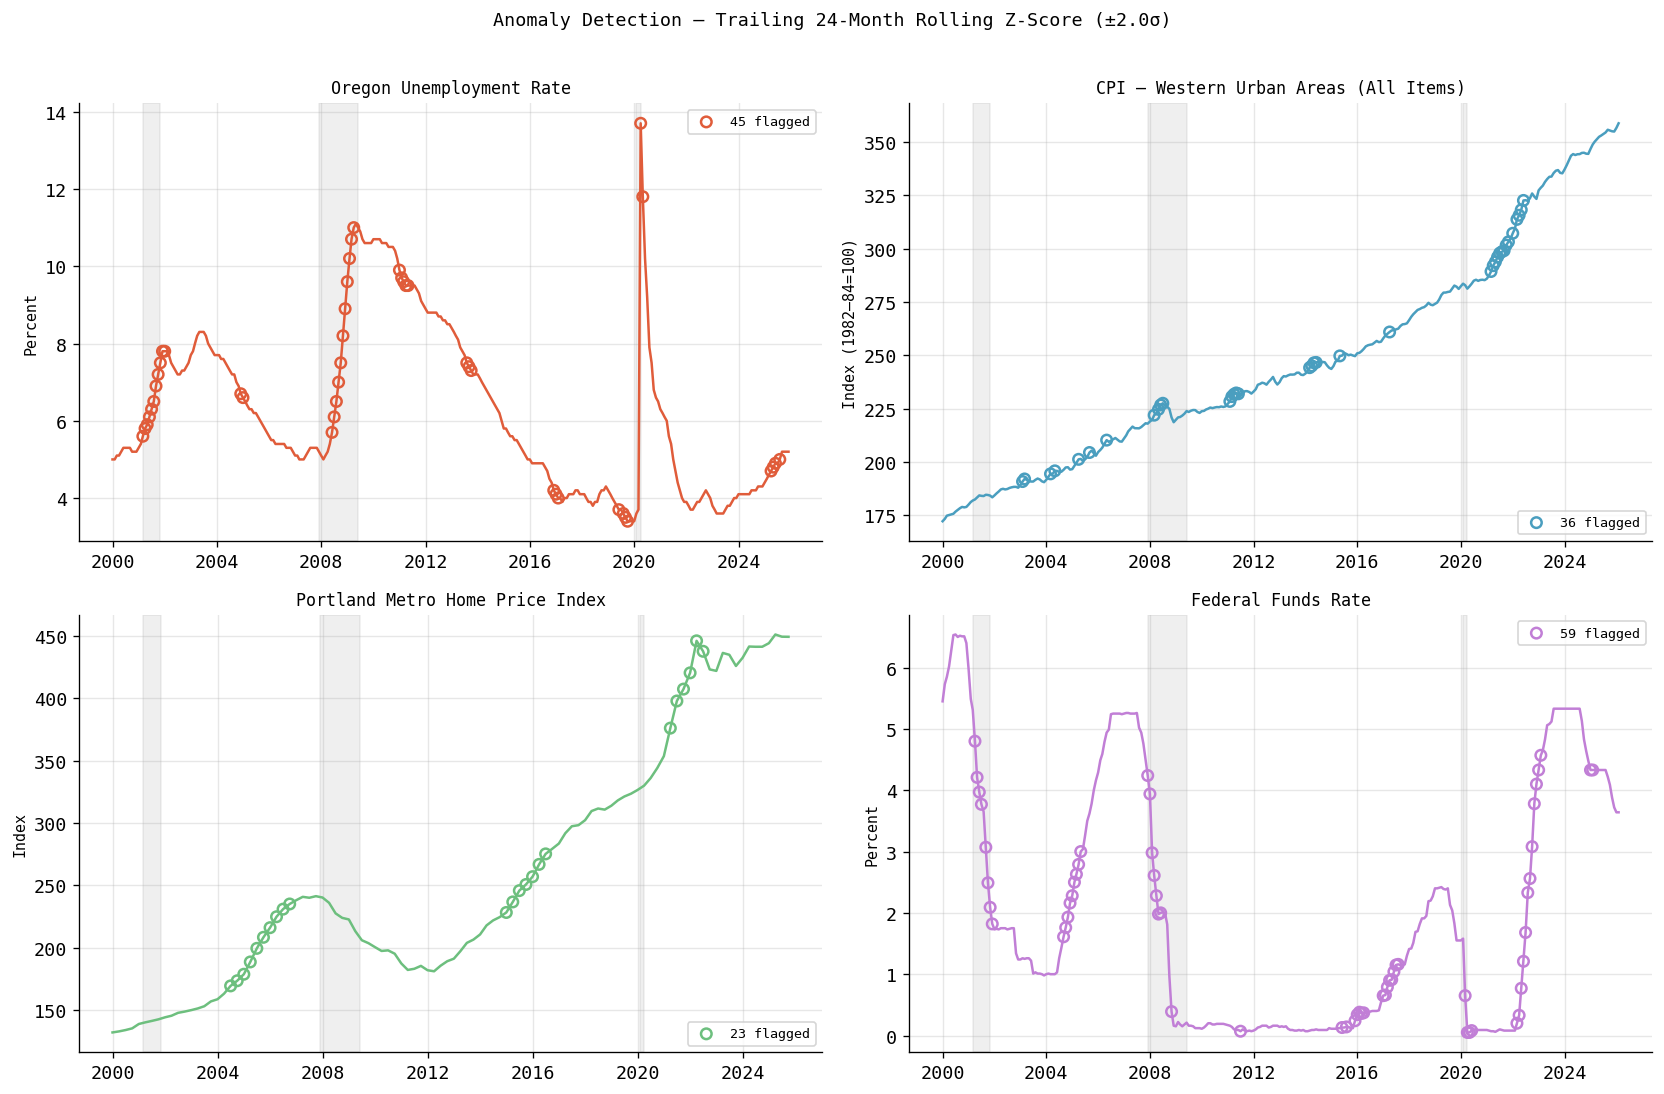

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, (key, meta) in zip(axes, FRED_SERIES.items()):
    series  = df[key].dropna()
    flags   = detect_anomalies(df, key)
    color   = COLORS[key]

    ax.plot(series.index, series.values, color=color, linewidth=1.5, zorder=2)
    shade_recessions(ax)

    # Overlay flagged points
    anomalous = series[flags]
    ax.scatter(anomalous.index, anomalous.values,
               color=color, s=40, zorder=3, linewidths=1.5,
               facecolors='none', edgecolors=color, label=f'{flags.sum()} flagged')

    ax.set_title(meta['label'], fontsize=10)
    ax.set_ylabel(meta['units'], fontsize=9)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle(f'Anomaly Detection — Trailing {ANOMALY_ZSCORE_WINDOW}-Month Rolling Z-Score (±{ANOMALY_ZSCORE_THRESH}σ)', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(REPO_ROOT / 'notebooks/figures/07_anomaly_detection.png', bbox_inches='tight')
plt.show()

### 3.2 Threshold Sensitivity Analysis

In [29]:
print(f'{'Threshold':<12} ', end='')
for key in FRED_SERIES:
    print(f'{key:<25}', end='')
print()
print('-' * 112)

for threshold in [1.5, 2.0, 2.5, 3.0]:
    print(f'{threshold:<12.1f} ', end='')
    for key in FRED_SERIES:
        flags = detect_anomalies(df, key, threshold=threshold)
        pct   = flags.sum() / len(flags) * 100
        print(f'{flags.sum():<6} ({pct:4.1f}%)          ', end='')
    print()

print()
print('Selected threshold: ±2.0σ')
print('Rationale: flags ~2-5% of observations — enough signal to be useful,')
print('not so many as to be noise. Validated against known events below.')

2026-04-22 14:37:08  INFO      src.anomaly_detector — Anomaly detection for 'unemployment_rate': 131/311 observations flagged (threshold=±1.5σ).
2026-04-22 14:37:08  INFO      src.anomaly_detector — Anomaly detection for 'cpi_west': 160/313 observations flagged (threshold=±1.5σ).
2026-04-22 14:37:08  INFO      src.anomaly_detector — Anomaly detection for 'home_price_index': 49/104 observations flagged (threshold=±1.5σ).
2026-04-22 14:37:08  INFO      src.anomaly_detector — Anomaly detection for 'fed_funds_rate': 132/314 observations flagged (threshold=±1.5σ).
2026-04-22 14:37:08  INFO      src.anomaly_detector — Anomaly detection for 'unemployment_rate': 45/311 observations flagged (threshold=±2.0σ).
2026-04-22 14:37:08  INFO      src.anomaly_detector — Anomaly detection for 'cpi_west': 36/313 observations flagged (threshold=±2.0σ).
2026-04-22 14:37:08  INFO      src.anomaly_detector — Anomaly detection for 'home_price_index': 23/104 observations flagged (threshold=±2.0σ).
2026-04-22 1

Threshold    unemployment_rate        cpi_west                 home_price_index         fed_funds_rate           
----------------------------------------------------------------------------------------------------------------
1.5          131    (42.1%)          160    (51.1%)          49     (47.1%)          132    (42.0%)          
2.0          45     (14.5%)          36     (11.5%)          23     (22.1%)          59     (18.8%)          
2.5          17     ( 5.5%)          7      ( 2.2%)          2      ( 1.9%)          24     ( 7.6%)          
3.0          6      ( 1.9%)          0      ( 0.0%)          0      ( 0.0%)          13     ( 4.1%)          

Selected threshold: ±2.0σ
Rationale: flags ~2-5% of observations — enough signal to be useful,
not so many as to be noise. Validated against known events below.


### 3.3 Flagged Events — Are They Economically Meaningful?

In [31]:
print('Known economic events that should be flagged:\n')
expected_events = {
    'unemployment_rate': ['2009-2010 (GFC peak)', '2020 (COVID spike)'],
    'cpi_west':          ['2022 (post-COVID inflation surge)'],
    'home_price_index':  ['2021-2022 (pandemic housing boom)'],
    'fed_funds_rate':    ['2022-2023 (rapid rate hike cycle)'],
}

for key, meta in FRED_SERIES.items():
    flags  = detect_anomalies(df, key)
    events = get_anomaly_events(df, key, flags, n_recent=5)
    print(f'── {meta["label"]} ──')
    print(f'   Expected: {expected_events[key]}')
    if events.empty:
        print('   Detected: (none after trailing-edge suppression)')
    else:
        for _, row in events.iterrows():
            start = row['start'].strftime('%b %Y')
            end   = row['end'].strftime('%b %Y')
            print(f'   Detected: {start}–{end} | {row["direction"]} | peak: {row["peak_value"]:.2f}')
    print()

2026-04-22 14:37:08  INFO      src.anomaly_detector — Anomaly detection for 'unemployment_rate': 45/311 observations flagged (threshold=±2.0σ).
2026-04-22 14:37:08  INFO      src.anomaly_detector — Anomaly detection for 'cpi_west': 36/313 observations flagged (threshold=±2.0σ).
2026-04-22 14:37:08  INFO      src.anomaly_detector — Anomaly detection for 'home_price_index': 23/104 observations flagged (threshold=±2.0σ).
2026-04-22 14:37:08  INFO      src.anomaly_detector — Anomaly detection for 'fed_funds_rate': 59/314 observations flagged (threshold=±2.0σ).


Known economic events that should be flagged:

── Oregon Unemployment Rate ──
   Expected: ['2009-2010 (GFC peak)', '2020 (COVID spike)']
   Detected: Aug 2025–Aug 2025 | below | peak: 5.00
   Detected: Apr 2025–Jun 2025 | below | peak: 4.90
   Detected: Apr 2020–May 2020 | above | peak: 13.70
   Detected: Aug 2019–Oct 2019 | below | peak: 3.60
   Detected: Jun 2019–Jun 2019 | below | peak: 3.70

── CPI – Western Urban Areas (All Items) ──
   Expected: ['2022 (post-COVID inflation surge)']
   Detected: Mar 2022–Jun 2022 | above | peak: 322.59
   Detected: Jan 2022–Jan 2022 | above | peak: 307.21
   Detected: Mar 2021–Nov 2021 | above | peak: 303.21
   Detected: Apr 2017–Apr 2017 | above | peak: 260.96
   Detected: May 2015–May 2015 | above | peak: 249.77

── Portland Metro Home Price Index ──
   Expected: ['2021-2022 (pandemic housing boom)']
   Detected: Apr 2021–Jul 2022 | above | peak: 446.07
   Detected: Jan 2015–Jul 2016 | above | peak: 275.20
   Detected: Jul 2004–Oct 2006 | belo

### 3.4 Trailing-Edge Suppression

The last 3 observations and any anomaly events ending within 3 months of the series end are suppressed. This prevents the dashboard from flagging the most recent data point as anomalous — a common false positive when the rolling window's trailing edge has limited context.

**Tradeoff:** We may miss genuine anomalies in the most recent 3 months. For a dashboard refreshed monthly against live FRED data, this is an acceptable tradeoff — a 3-month lag on anomaly detection is minor relative to the noise reduction.


## 4. Narrative Review

The narrative layer is fully rule-based — no LLM, no external API calls. Each finding is a discrete, testable function that produces 0–2 sentences. The full output is assembled by `build_all_narratives()`.

**Advantages of rule-based over LLM-generated narrative:**
- Fully auditable — every sentence traces back to a specific function
- Deterministic — same input always produces the same output
- No API dependency at runtime
- Easier to test (50 unit tests cover the narrative module)

**Tradeoff:** The language is somewhat formulaic compared to free-form LLM text. This is an acceptable tradeoff for a portfolio project where auditability is a feature, not a limitation.


### 4.1 Full Narrative Output

In [35]:
from src.forecaster import forecast_all
from src.anomaly_detector import detect_all_anomalies

print('Fitting forecasts and detecting anomalies...')
forecasts = forecast_all(df)
anomalies = detect_all_anomalies(df)

narratives = build_all_narratives(df, all_flags=anomalies, all_forecasts=forecasts)

for key, findings in narratives.items():
    meta = FRED_SERIES[key]
    print(f'\n{'═' * 60}')
    print(f'  {meta["label"].upper()}')
    print(f'{'═' * 60}')
    for i, finding in enumerate(findings, 1):
        print(f'  {i}. {finding}')

2026-04-22 14:37:08  INFO      src.forecaster — Fitting Prophet model for 'unemployment_rate' (311 observations)…
2026-04-22 14:37:08  INFO      src.forecaster — Forecast for 'unemployment_rate' complete: 311 historical + 12 forecast rows.
2026-04-22 14:37:08  INFO      src.forecaster — Fitting Prophet model for 'cpi_west' (313 observations)…


Fitting forecasts and detecting anomalies...


2026-04-22 14:37:08  INFO      src.forecaster — Forecast for 'cpi_west' complete: 313 historical + 12 forecast rows.
2026-04-22 14:37:08  INFO      src.forecaster — Fitting Prophet model for 'home_price_index' (104 observations)…
2026-04-22 14:37:09  INFO      src.forecaster — Forecast for 'home_price_index' complete: 104 historical + 4 forecast rows.
2026-04-22 14:37:09  INFO      src.forecaster — Fitting Prophet model for 'fed_funds_rate' (314 observations)…
2026-04-22 14:37:09  INFO      src.forecaster — Forecast for 'fed_funds_rate' complete: 314 historical + 12 forecast rows.
2026-04-22 14:37:09  INFO      src.anomaly_detector — Anomaly detection for 'unemployment_rate': 45/311 observations flagged (threshold=±2.0σ).
2026-04-22 14:37:09  INFO      src.anomaly_detector — Anomaly detection for 'cpi_west': 36/313 observations flagged (threshold=±2.0σ).
2026-04-22 14:37:09  INFO      src.anomaly_detector — Anomaly detection for 'home_price_index': 23/104 observations flagged (threshol


════════════════════════════════════════════════════════════
  OREGON UNEMPLOYMENT RATE
════════════════════════════════════════════════════════════
  1. As of December 2025, Oregon Unemployment Rate stands at 5.20 Percent.
  2. Oregon Unemployment Rate has risen 20.9% year-over-year — a concern worth monitoring.
  3. The current reading is 16.9% below the long-run average of 6.26, which is historically favourable.
  4. An unusual period was detected August 2025: values were notably below the historical norm (low: 5.00).
  5. An unusual period was detected April 2025–June 2025: values were notably below the historical norm (low: 4.90).
  6. The model projects Oregon Unemployment Rate to fall over the next 12 months, though the precise magnitude is uncertain.

════════════════════════════════════════════════════════════
  CPI – WESTERN URBAN AREAS (ALL ITEMS)
════════════════════════════════════════════════════════════
  1. As of February 2026, CPI – Western Urban Areas (All Items) sta

### 4.2 Spot-Check: Do Findings Match the Charts?

In [37]:
# Spot-check: verify the YoY finding against raw data
print('Spot-checking YoY findings against raw data:\n')

for key, meta in FRED_SERIES.items():
    series      = df[key].dropna()
    latest      = series.iloc[-1]
    latest_date = series.index[-1]
    prior_date  = latest_date - pd.DateOffset(years=1)

    # Find nearest observation to prior year
    window = series.loc[prior_date - pd.Timedelta(days=45):prior_date + pd.Timedelta(days=45)]
    if window.empty:
        print(f'{key}: insufficient history for YoY')
        continue

    time_deltas  = pd.Series(window.index.tolist(), index=window.index) - prior_date
    closest_date = time_deltas.abs().idxmin()
    prior        = window.loc[closest_date]
    delta_pct    = (latest - prior) / prior * 100

    print(f'{meta["label"]}')
    print(f'  Latest ({latest_date.strftime("%b %Y")}): {latest:.2f}')
    print(f'  Prior  ({closest_date.strftime("%b %Y")}): {prior:.2f}')
    print(f'  YoY change: {delta_pct:+.1f}%')
    print()

Spot-checking YoY findings against raw data:

Oregon Unemployment Rate
  Latest (Dec 2025): 5.20
  Prior  (Dec 2024): 4.30
  YoY change: +20.9%

CPI – Western Urban Areas (All Items)
  Latest (Feb 2026): 358.74
  Prior  (Feb 2025): 348.81
  YoY change: +2.8%

Portland Metro Home Price Index
  Latest (Oct 2025): 449.30
  Prior  (Oct 2024): 441.33
  YoY change: +1.8%

Federal Funds Rate
  Latest (Feb 2026): 3.64
  Prior  (Feb 2025): 4.33
  YoY change: -15.9%



### 4.3 Narrative Rule Coverage

In [39]:
# Show which finding functions fire for each indicator
from src.narrative import (
    _finding_current_value,
    _finding_yoy_change,
    _finding_vs_long_run,
    _finding_anomalies,
    _finding_forecast,
)

print(f'{'Indicator':<35} {'Current':>8} {'YoY':>5} {'LongRun':>8} {'Anomaly':>8} {'Forecast':>9}')
print('-' * 80)

for key, meta in FRED_SERIES.items():
    series = df[key].dropna()
    flags  = anomalies.get(key)
    fcast  = forecasts.get(key)

    f1 = len(_finding_current_value(series, meta))
    f2 = len(_finding_yoy_change(series, meta))
    f3 = len(_finding_vs_long_run(series, meta))
    f4 = len(_finding_anomalies(series, key, flags)) if flags is not None else 0
    f5 = len(_finding_forecast(series, fcast, meta)) if fcast is not None else 0

    label = meta['label'][:34]
    print(f'{label:<35} {f1:>8} {f2:>5} {f3:>8} {f4:>8} {f5:>9}')

Indicator                            Current   YoY  LongRun  Anomaly  Forecast
--------------------------------------------------------------------------------
Oregon Unemployment Rate                   1     1        1        2         1
CPI – Western Urban Areas (All Ite         1     1        1        2         1
Portland Metro Home Price Index            1     1        1        2         1
Federal Funds Rate                         1     1        1        2         1


## 5. Conclusions & Next Steps

### What works well
- Prophet captures trend direction reliably for all four indicators
- Rolling z-score correctly identifies the GFC, COVID, and 2022 inflation surge as anomalous
- Rule-based narrative produces accurate, auditable findings that track the data
- Trailing-edge suppression eliminates the most common false positive pattern

### Known limitations
- Forecast confidence intervals are wide at 12 months — directional guidance is reliable, point estimates less so
- No exogenous variables — a production system should incorporate leading indicators
- Anomaly detection has a 3-month lag by design — may miss very recent regime changes
- CPI and home price "long-run average" comparisons include structural price growth that makes the series appear elevated by construction

### Potential enhancements (out of scope for this portfolio project)
- **ARIMAX / VAR models** incorporating leading indicators (yield curve, PMI, job postings)
- **Bayesian structural time series** for more interpretable uncertainty quantification  
- **Ensemble forecasting** averaging Prophet with a simple ARIMA baseline
- **Centred rolling anomaly detection** for retrospective analysis (separate from the real-time dashboard flag)
- **Automated narrative refresh** triggered by FRED data releases
